# KNN Model Training & Tuning

This notebook trains a KNN classifier on the linearized session windows data using all available numerical features.
We use `RandomizedSearchCV` with a single static validation split (`PredefinedSplit`) to tune key hyperparameters of the model.

Since the final model will be evaluated against real data from the database, we use the holdout validation set solely for hyperparameter tuning. The model is also evaluated on the real database export dataset.

In [30]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add project root directory to path for imports
sys.path.append(str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, train_test_split
from scripts.data_loader import load_and_preprocess_data
from scripts.evaluation_metrics import evaluate_model

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load and Preprocess Data

We load the data and extract scaled features, targets, and the fitted scaler using our shared preprocessing script.

In [31]:
X_train, X_test, y_train, y_test, scaler = load_and_preprocess_data()
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (9081, 42)
Test set shape: (2271, 42)


## Hyperparameter Tuning via Randomized Search

We use a static validation split (holdout set) rather than K-Fold cross-validation to save compute time. We search across larger values of n_neighbors to smooth out KNN decision boundaries and combat overfitting. 

*Note on Distance Weighting*: If weights='distance' is selected, training accuracy will naturally be close to 100% because each training point has distance 0 to itself and gets infinite weight. To check for true generalization, we rely on the validation set score and test set metrics.

In [32]:
param_dist = {
    'n_neighbors': [5, 9, 13, 17, 21, 25, 29, 33, 37, 41],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],
    'leaf_size': [20, 30, 40, 50]
}

# Split training data to create a single static validation set (holdout)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Create a PredefinedSplit where training is -1 and validation is 0
split_index = [-1] * len(X_tr) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

# Combine train and validation sets back together for fit()
X_tune = pd.concat([X_tr, X_val])
y_tune = pd.concat([y_tr, y_val])

base_model = KNeighborsClassifier()

random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=pds,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_tune, y_tune)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Validation Accuracy: {random_search.best_score_:.4f}")

Best Parameters: {'weights': 'distance', 'p': 1, 'n_neighbors': 17, 'metric': 'minkowski', 'leaf_size': 20}
Best Validation Accuracy: 0.6896


## Evaluate Best Model

We evaluate the optimized model on the test split of the training dataset.


--- Train Metrics ---
Accuracy:  1.0000
Precision (weighted): 1.0000
Recall (weighted):    1.0000
F1 Score (weighted):  1.0000

--- Test/Validation Metrics ---
Accuracy:  0.6715
Precision (weighted): 0.6580
Recall (weighted):    0.6715
F1 Score (weighted):  0.6558


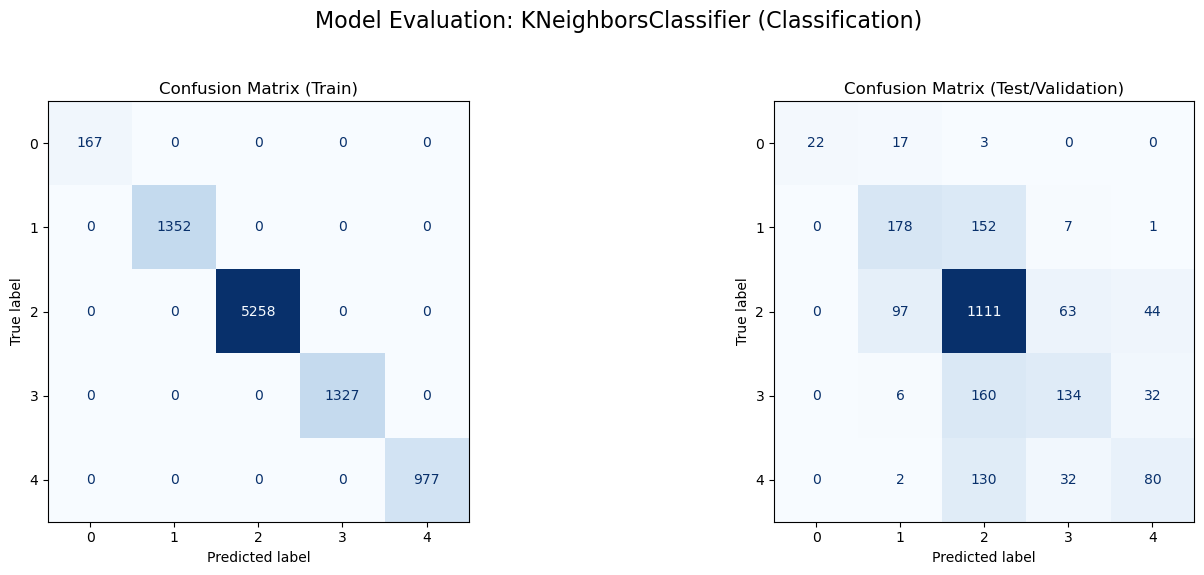

In [33]:
best_model = random_search.best_estimator_
figures = evaluate_model(best_model, X_train, X_test, y_train, y_test, is_classification=True)

Overfitting on train set, duh, it's knn, it's literally finding 0 distance when looking for closest points.

## Evaluate on Real Production Data

We load the real session data exported from the database, scale it using the same scaler fitted on our training data, and evaluate our tuned model on it.

In [34]:
# Path to real data generated from the production database
real_data_path = Path("../../data/real/linearized_sessions_with_target.csv")

if real_data_path.exists() and real_data_path.stat().st_size > 0:
    try:
        real_df = pd.read_csv(real_data_path).dropna(subset=["rating"])
        if not real_df.empty:
            # Select features (must match the same feature columns used in training)
            X_real = real_df[X_train.columns]
            y_real = real_df["rating"]
            
            # CRITICAL: Scale real features using the SAME scaler fitted on training data
            X_real_scaled = pd.DataFrame(
                scaler.transform(X_real),
                columns=X_real.columns,
                index=X_real.index
            )
            
            print(f"Loaded {len(real_df)} real sessions for evaluation.")
            # Evaluate using the same evaluation script
            figs_real = evaluate_model(best_model, X_train, X_real_scaled, y_train, y_real, is_classification=True)
        else:
            print("Real data CSV is empty.")
    except Exception as e:
        print(f"Could not load or evaluate real data: {e}")
else:
    print(f"No real data available for testing at: {real_data_path}")

Could not load or evaluate real data: No columns to parse from file
